# 边界优化分析

可视化 WLS 约束优化触发边界调整（因子池迭代）的全过程。

数据来源：运行 `纯债基金久期测算.ipynb` 后生成的 `久期迭代日志_YYYYMMDD.xlsx`

## 内容目录
1. 边界触发整体统计
2. 收敛类型分布
3. 迭代轮数分布
4. 边界类型分析（upper vs lower）
5. 因子池动态（最常添加/移除的因子）
6. 典型基金迭代过程追踪

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 配置：修改此处以切换分析日期 ────────────────────────────────────────
TARGET_DATE = '20251231'   # 与文件名中的日期对应
LOG_FILE = f'./output/久期迭代日志_{TARGET_DATE}.xlsx'
# ─────────────────────────────────────────────────────────────────────────

print(f'读取日志文件: {LOG_FILE}')
df_all    = pd.read_excel(LOG_FILE, sheet_name='全量汇总')
df_trig   = pd.read_excel(LOG_FILE, sheet_name='触发汇总')
df_detail = pd.read_excel(LOG_FILE, sheet_name='迭代详情')

print(f'全量汇总:  {len(df_all)} 只基金')
print(f'触发汇总:  {len(df_trig)} 只基金触发边界')
print(f'迭代详情:  {len(df_detail)} 条迭代记录')
df_all.head(3)

读取日志文件: ./output/久期迭代日志_20251231.xlsx
全量汇总:  1563 只基金
触发汇总:  1294 只基金触发边界
迭代详情:  4764 条迭代记录


,fund_code,fund_type,bond_type,final_duration,triggered,total_iterations,convergence,initial_factor_count,final_factor_count,initial_factors,final_factors
0,000084.OF,short,credit,1.375068,True,1,no_valid_swap,5,3,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01831.CS, CBA01861.CS, CBA02821.CS"
1,000089.OF,short,credit,0.720912,True,2,interior,5,4,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01841.CS, CBA01851.CS, CBA02821.CS, CBA0186..."
2,000128.OF,short,credit,2.222924,True,1,no_valid_swap,5,4,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01831.CS, CBA01851.CS, CBA01861.CS, CBA0282..."


---
## Section 1：边界触发整体统计

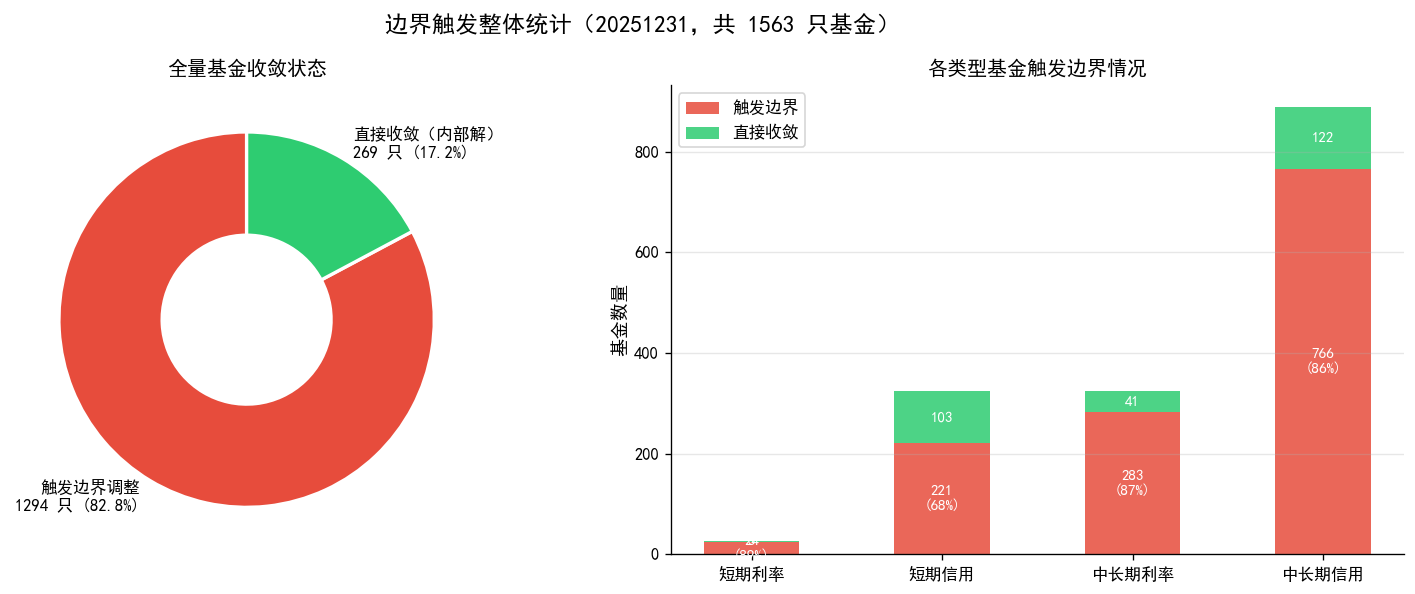


各类型触发统计：
label  total  triggered  interior  trig_pct
 短期利率     27         24         3 88.888889
 短期信用    324        221       103 68.209877
中长期利率    324        283        41 87.345679
中长期信用    888        766       122 86.261261


In [2]:
# ── 数据准备 ─────────────────────────────────────────────────────────────
n_total    = len(df_all)
n_triggered = df_all['triggered'].sum()
n_interior  = n_total - n_triggered

# 4类基金的触发比例
df_all['category'] = df_all['fund_type'].fillna('unknown') + '_' + df_all['bond_type'].fillna('unknown')
cat_order = ['short_rate', 'short_credit', 'medium_long_rate', 'medium_long_credit']
cat_labels = {'short_rate': '短期利率', 'short_credit': '短期信用',
              'medium_long_rate': '中长期利率', 'medium_long_credit': '中长期信用'}

cat_stats = []
for cat in cat_order:
    sub = df_all[df_all['category'] == cat]
    total = len(sub)
    trig  = sub['triggered'].sum()
    cat_stats.append({'cat': cat, 'label': cat_labels.get(cat, cat),
                      'total': total, 'triggered': trig,
                      'interior': total - trig,
                      'trig_pct': trig / total * 100 if total > 0 else 0})
cat_df = pd.DataFrame(cat_stats)

# ── 绘图 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'边界触发整体统计（{TARGET_DATE}，共 {n_total} 只基金）', fontsize=14, fontweight='bold')

# 左：全量饼图
ax = axes[0]
sizes  = [n_triggered, n_interior]
labels = [f'触发边界调整\n{n_triggered} 只 ({n_triggered/n_total*100:.1f}%)',
          f'直接收敛（内部解）\n{n_interior} 只 ({n_interior/n_total*100:.1f}%)']
colors = ['#e74c3c', '#2ecc71']
wedges, texts = ax.pie(sizes, labels=labels, colors=colors, startangle=90,
                        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for t in texts:
    t.set_fontsize(10)
ax.set_title('全量基金收敛状态', fontsize=12)

# 右：4类基金触发比例堆积柱状图
ax = axes[1]
x = np.arange(len(cat_df))
bar_w = 0.5
b1 = ax.bar(x, cat_df['triggered'], bar_w, label='触发边界', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x, cat_df['interior'],  bar_w, bottom=cat_df['triggered'],
            label='直接收敛', color='#2ecc71', alpha=0.85)

# 在每段上标注数量和百分比
for i, row in cat_df.iterrows():
    if row['triggered'] > 0:
        ax.text(i, row['triggered'] / 2, f"{int(row['triggered'])}\n({row['trig_pct']:.0f}%)",
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if row['interior'] > 0:
        ax.text(i, row['triggered'] + row['interior'] / 2,
                f"{int(row['interior'])}",
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cat_df['label'], fontsize=10)
ax.set_ylabel('基金数量', fontsize=11)
ax.set_title('各类型基金触发边界情况', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'边界触发统计_{TARGET_DATE}.png', bbox_inches='tight')
plt.show()
print('\n各类型触发统计：')
print(cat_df[['label', 'total', 'triggered', 'interior', 'trig_pct']].to_string(index=False))

---
## Section 2：收敛类型分布

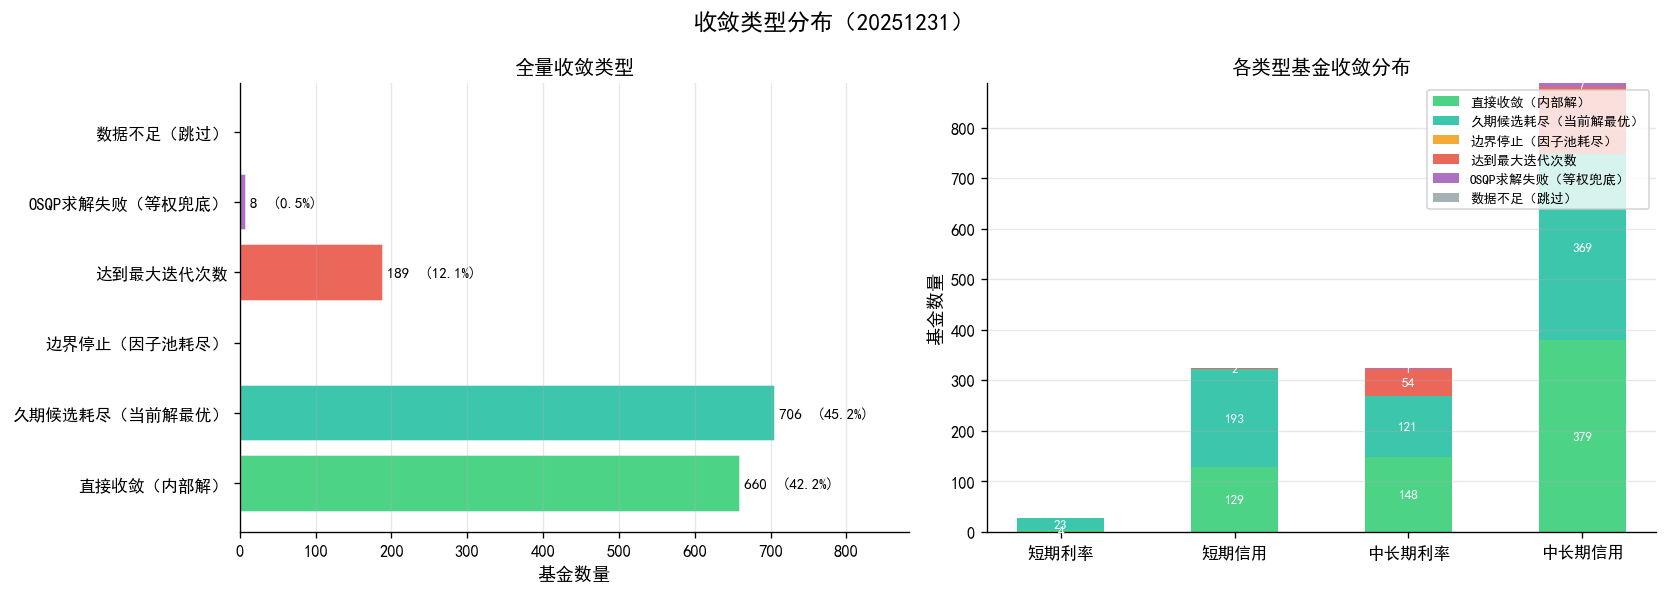

In [3]:
# ── 数据准备 ─────────────────────────────────────────────────────────────
conv_map = {
    'interior':       '直接收敛（内部解）',
    'no_valid_swap':  '久期候选耗尽（当前解最优）',
    'boundary':       '边界停止（因子池耗尽）',
    'max_iter':       '达到最大迭代次数',
    'fallback':       'OSQP求解失败（等权兜底）',
    'data_error':     '数据不足（跳过）',
}
conv_colors = {
    'interior':       '#2ecc71',
    'no_valid_swap':  '#1abc9c',
    'boundary':       '#f39c12',
    'max_iter':       '#e74c3c',
    'fallback':       '#9b59b6',
    'data_error':     '#95a5a6',
}

# 全量收敛类型分布
conv_total = df_all['convergence'].value_counts().reindex(list(conv_map.keys()), fill_value=0)

# 分类别
conv_by_cat = {}
for cat in cat_order:
    sub = df_all[df_all['category'] == cat]
    conv_by_cat[cat] = sub['convergence'].value_counts().reindex(list(conv_map.keys()), fill_value=0)

# ── 绘图 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'收敛类型分布（{TARGET_DATE}）', fontsize=14, fontweight='bold')

# 左：全量横向柱状图
ax = axes[0]
conv_keys   = list(conv_map.keys())
conv_labels = [conv_map[k] for k in conv_keys]
conv_vals   = [conv_total.get(k, 0) for k in conv_keys]
colors_list = [conv_colors[k] for k in conv_keys]
bars = ax.barh(conv_labels, conv_vals, color=colors_list, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, conv_vals):
    if val > 0:
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                f'{val}  ({val/n_total*100:.1f}%)',
                va='center', fontsize=9)
ax.set_xlabel('基金数量', fontsize=11)
ax.set_title('全量收敛类型', fontsize=12)
ax.set_xlim(0, max(conv_vals) * 1.25 if max(conv_vals) > 0 else 10)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# 右：堆积柱状图（按基金类型）
ax = axes[1]
x = np.arange(len(cat_order))
bottoms = np.zeros(len(cat_order))
for k in conv_keys:
    vals = np.array([conv_by_cat[cat].get(k, 0) for cat in cat_order], dtype=float)
    bars = ax.bar(x, vals, 0.5, bottom=bottoms,
                  label=conv_map[k], color=conv_colors[k], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax.text(i, b + v / 2, str(int(v)), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels([cat_labels[c] for c in cat_order], fontsize=10)
ax.set_ylabel('基金数量', fontsize=11)
ax.set_title('各类型基金收敛分布', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'收敛类型分布_{TARGET_DATE}.png', bbox_inches='tight')
plt.show()


---
## Section 3：迭代轮数分布

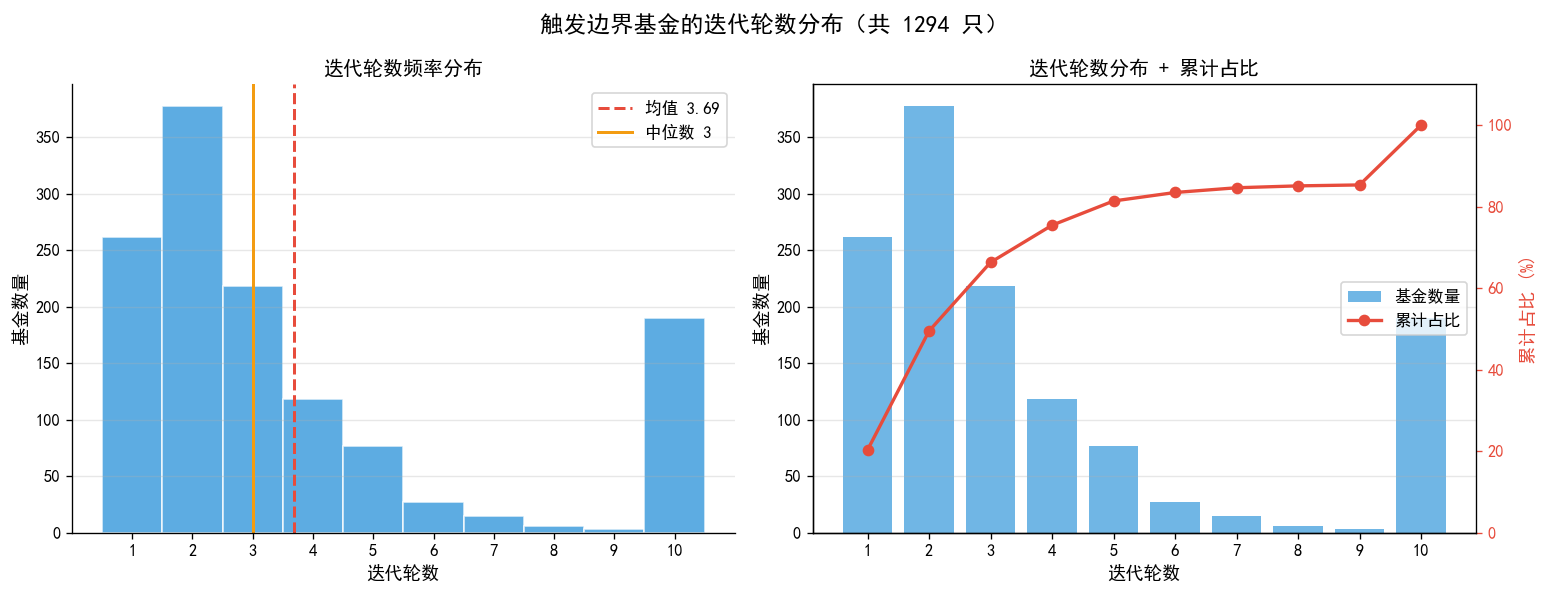


迭代轮数统计（触发基金）：
  均值:   3.69
  中位数: 3
  最大值: 10

轮次分布：
  1 轮: 262 只 (20.2%)
  2 轮: 378 只 (29.2%)
  3 轮: 218 只 (16.8%)
  4 轮: 118 只 (9.1%)
  5 轮: 77 只 (6.0%)
  6 轮: 27 只 (2.1%)
  7 轮: 15 只 (1.2%)
  8 轮: 6 只 (0.5%)
  9 轮: 3 只 (0.2%)
  10 轮: 190 只 (14.7%)


In [4]:
# 只取触发边界的基金
trig_iters = df_trig['total_iterations'].dropna().astype(int)

if len(trig_iters) == 0:
    print('没有触发边界的基金，跳过本节。')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'触发边界基金的迭代轮数分布（共 {len(trig_iters)} 只）', fontsize=14, fontweight='bold')

    # 左：直方图
    ax = axes[0]
    max_iter = trig_iters.max()
    bins = np.arange(0.5, max_iter + 1.5, 1)
    ax.hist(trig_iters, bins=bins, color='#3498db', alpha=0.8, edgecolor='white')
    mean_val   = trig_iters.mean()
    median_val = trig_iters.median()
    ax.axvline(mean_val,   color='#e74c3c', linestyle='--', linewidth=1.8,
               label=f'均值 {mean_val:.2f}')
    ax.axvline(median_val, color='#f39c12', linestyle='-',  linewidth=1.8,
               label=f'中位数 {median_val:.0f}')
    ax.set_xlabel('迭代轮数', fontsize=11)
    ax.set_ylabel('基金数量', fontsize=11)
    ax.set_title('迭代轮数频率分布', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(range(1, max_iter + 1))
    ax.spines[['top', 'right']].set_visible(False)

    # 右：按迭代轮数累计百分比
    ax = axes[1]
    vc = trig_iters.value_counts().sort_index()
    cum_pct = (vc.cumsum() / len(trig_iters) * 100)
    ax.bar(vc.index, vc.values, color='#3498db', alpha=0.7, label='基金数量')
    ax2 = ax.twinx()
    ax2.plot(vc.index, cum_pct.values, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='累计占比')
    ax2.set_ylabel('累计占比 (%)', fontsize=11, color='#e74c3c')
    ax2.set_ylim(0, 110)
    ax2.tick_params(axis='y', colors='#e74c3c')
    ax.set_xlabel('迭代轮数', fontsize=11)
    ax.set_ylabel('基金数量', fontsize=11)
    ax.set_title('迭代轮数分布 + 累计占比', fontsize=12)
    ax.set_xticks(vc.index)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='center right')

    plt.tight_layout()
    plt.savefig(f'迭代轮数分布_{TARGET_DATE}.png', bbox_inches='tight')
    plt.show()

    print(f'\n迭代轮数统计（触发基金）：')
    print(f'  均值:   {mean_val:.2f}')
    print(f'  中位数: {median_val:.0f}')
    print(f'  最大值: {max_iter}')
    print(f'\n轮次分布：')
    for k, v in vc.items():
        print(f'  {k} 轮: {v} 只 ({v/len(trig_iters)*100:.1f}%)')

---
## Section 4：边界类型分析（upper vs lower）

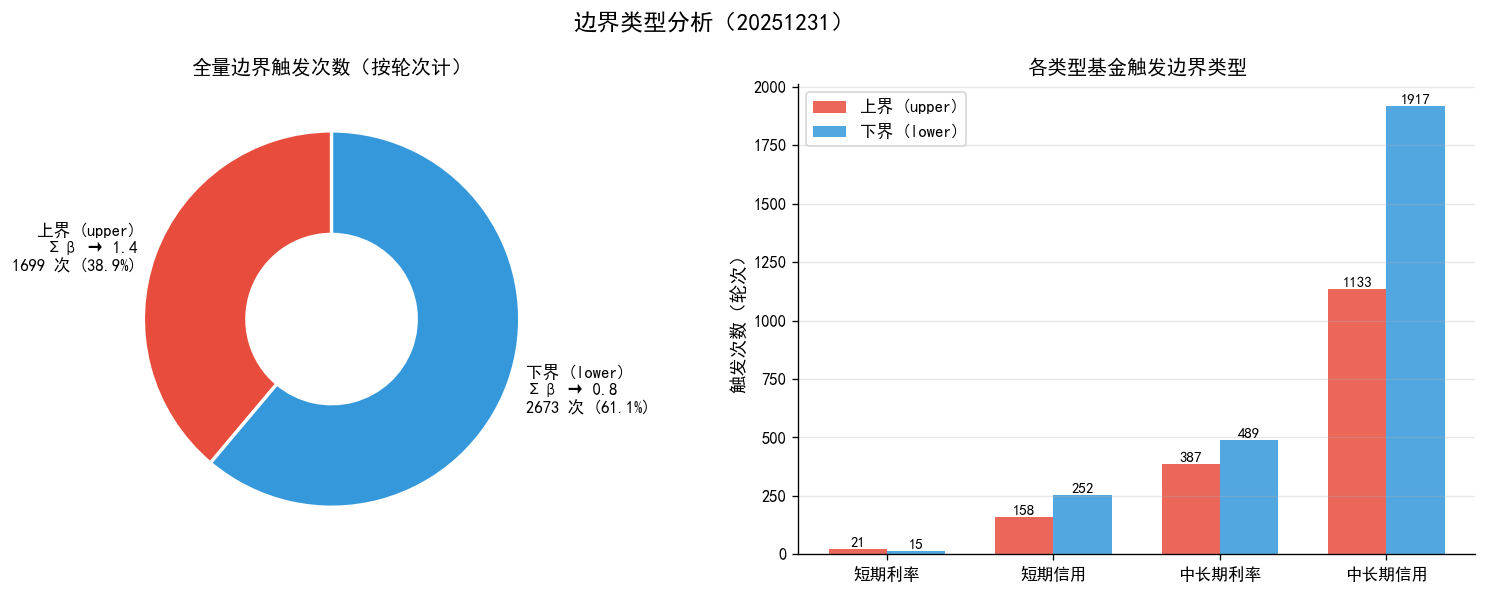


上界(upper)：Σβ = 1.4，杠杆超上限，说明现有因子组合久期偏低，模型倾向加大仓位
下界(lower)：Σβ = 0.8，杠杆超下限，说明现有因子组合久期偏高，模型倾向减仓


In [5]:
# 从迭代详情中统计各轮次触发的边界类型
# 只看真正在边界上的轮次（排除 interior 轮）
df_bnd = df_detail[df_detail['boundary_type'].isin(['upper', 'lower'])].copy()

if len(df_bnd) == 0:
    print('没有边界触发记录，跳过本节。')
else:
    # 合并分类信息
    df_bnd = df_bnd.merge(
        df_all[['fund_code', 'category']].drop_duplicates(),
        on='fund_code', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'边界类型分析（{TARGET_DATE}）', fontsize=14, fontweight='bold')

    # 左：全量 upper vs lower 饼图
    ax = axes[0]
    bnd_counts = df_bnd['boundary_type'].value_counts()
    n_up  = bnd_counts.get('upper', 0)
    n_lo  = bnd_counts.get('lower', 0)
    sizes  = [n_up, n_lo]
    labels = [f'上界 (upper)\nΣβ → {1.4}\n{n_up} 次 ({n_up/(n_up+n_lo)*100:.1f}%)',
              f'下界 (lower)\nΣβ → {0.8}\n{n_lo} 次 ({n_lo/(n_up+n_lo)*100:.1f}%)']
    colors = ['#e74c3c', '#3498db']
    ax.pie(sizes, labels=labels, colors=colors, startangle=90,
           wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
    ax.set_title('全量边界触发次数（按轮次计）', fontsize=12)

    # 右：各类型基金的 upper/lower 触发次数
    ax = axes[1]
    x = np.arange(len(cat_order))
    bnd_cat = df_bnd.groupby(['category', 'boundary_type']).size().unstack(fill_value=0)
    up_vals = np.array([bnd_cat.get('upper', pd.Series()).get(c, 0) for c in cat_order])
    lo_vals = np.array([bnd_cat.get('lower', pd.Series()).get(c, 0) for c in cat_order])
    bar_w = 0.35
    b1 = ax.bar(x - bar_w/2, up_vals, bar_w, label='上界 (upper)', color='#e74c3c', alpha=0.85)
    b2 = ax.bar(x + bar_w/2, lo_vals, bar_w, label='下界 (lower)', color='#3498db', alpha=0.85)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    str(int(h)), ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([cat_labels.get(c, c) for c in cat_order], fontsize=10)
    ax.set_ylabel('触发次数（轮次）', fontsize=11)
    ax.set_title('各类型基金触发边界类型', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'边界类型分析_{TARGET_DATE}.png', bbox_inches='tight')
    plt.show()

    print(f'\n上界(upper)：Σβ = {1.4}，杠杆超上限，说明现有因子组合久期偏低，模型倾向加大仓位')
    print(f'下界(lower)：Σβ = {0.8}，杠杆超下限，说明现有因子组合久期偏高，模型倾向减仓')

---
## Section 5：因子池动态（最常添加/移除的因子）

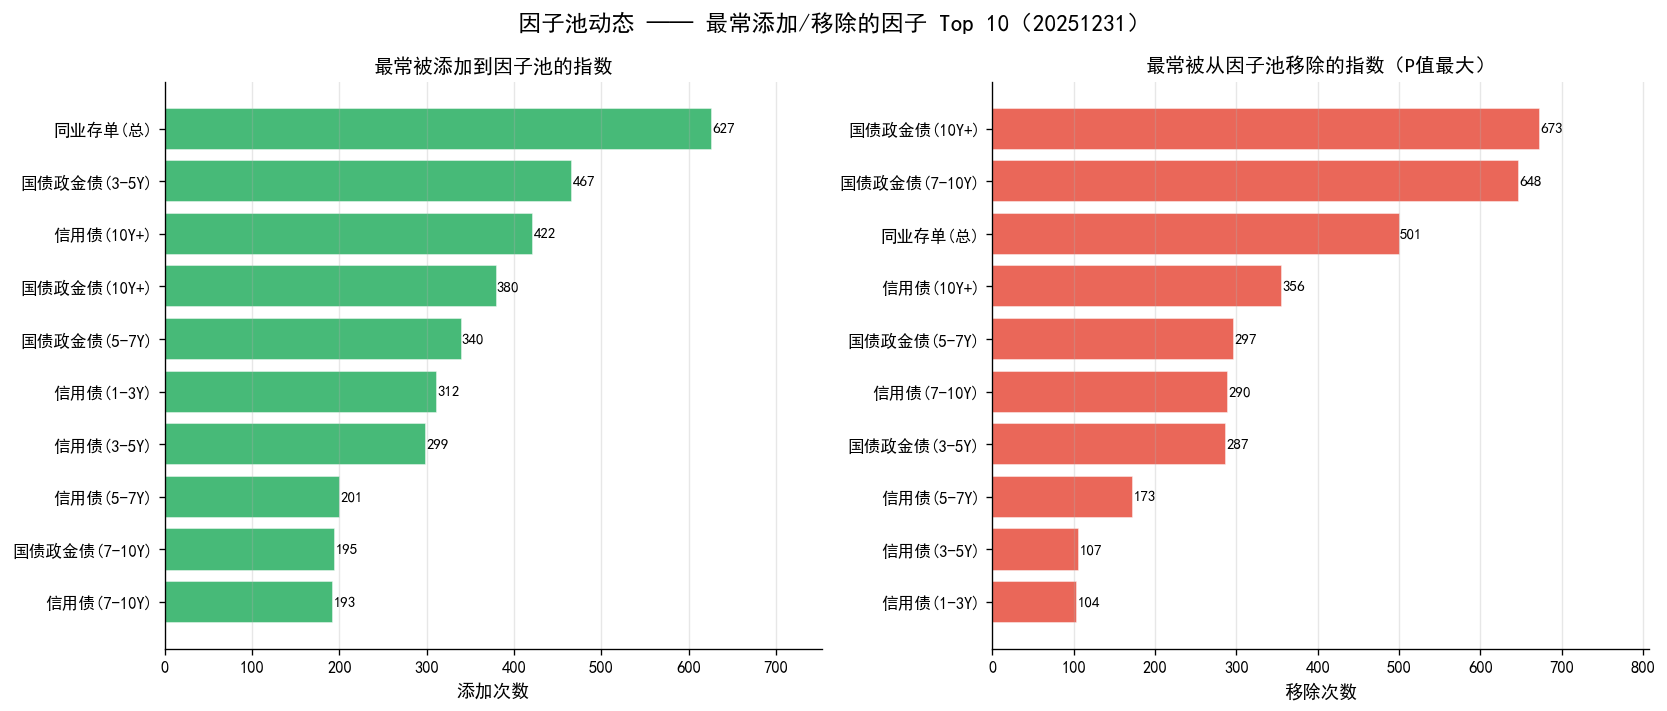


Top5 因子添加 vs 移除对比：
               添加最多   移除最多
信用债(10Y+)     422.0  356.0
同业存单(总)       627.0  501.0
国债政金债(10Y+)   380.0  673.0
国债政金债(3-5Y)   467.0    NaN
国债政金债(5-7Y)   340.0  297.0
国债政金债(7-10Y)    NaN  648.0


In [6]:
# 指数代码 → 可读名称映射
INDEX_NAMES = {
    'CBA05821.CS': '国债政金债(1-3Y)',
    'CBA05831.CS': '国债政金债(3-5Y)',
    'CBA05841.CS': '国债政金债(5-7Y)',
    'CBA05851.CS': '国债政金债(7-10Y)',
    'CBA05861.CS': '国债政金债(10Y+)',
    'CBA07501.CS': '同业存单(总)',
    'CBA07511.CS': '同业存单(0-3M)',
    'CBA07521.CS': '同业存单(3-6M)',
    'CBA07531.CS': '同业存单(6-9M)',
    'CBA07541.CS': '同业存单(9-12M)',
    'CBA02711.CS': '信用债(1Y以下)',
    'CBA02721.CS': '信用债(1-3Y)',
    'CBA02731.CS': '信用债(3-5Y)',
    'CBA02741.CS': '信用债(5-7Y)',
    'CBA02751.CS': '信用债(7-10Y)',
    'CBA02761.CS': '信用债(10Y+)',
    'CBA01831.CS': '短融(0-3M)',
    'CBA01841.CS': '短融(3-6M)',
    'CBA01851.CS': '短融(6-9M)',
    'CBA01861.CS': '短融(9-12M)',
    'CBA02821.CS': '中票(1-3Y)',
}

def code_to_name(code):
    return INDEX_NAMES.get(str(code).strip(), str(code))

# 统计添加/移除频次
df_detail_notna = df_detail.dropna(subset=['factor_added', 'factor_removed'], how='all')
add_counts = df_detail_notna['factor_added'].dropna().value_counts()
rem_counts = df_detail_notna['factor_removed'].dropna().value_counts()

TOP_N = min(10, max(len(add_counts), len(rem_counts)))

if TOP_N == 0:
    print('没有因子变动记录，跳过本节。')
else:
    add_top = add_counts.head(TOP_N)
    rem_top = rem_counts.head(TOP_N)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, TOP_N * 0.5 + 1)))
    fig.suptitle(f'因子池动态 —— 最常添加/移除的因子 Top {TOP_N}（{TARGET_DATE}）',
                 fontsize=14, fontweight='bold')

    # 左：最常被添加的因子
    ax = axes[0]
    y_labels = [code_to_name(c) for c in add_top.index]
    bars = ax.barh(y_labels[::-1], add_top.values[::-1],
                   color='#27ae60', alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, add_top.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(int(val)), va='center', fontsize=9)
    ax.set_xlabel('添加次数', fontsize=11)
    ax.set_title('最常被添加到因子池的指数', fontsize=12)
    ax.set_xlim(0, add_top.max() * 1.2)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # 右：最常被移除的因子
    ax = axes[1]
    y_labels = [code_to_name(c) for c in rem_top.index]
    bars = ax.barh(y_labels[::-1], rem_top.values[::-1],
                   color='#e74c3c', alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, rem_top.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(int(val)), va='center', fontsize=9)
    ax.set_xlabel('移除次数', fontsize=11)
    ax.set_title('最常被从因子池移除的指数（P值最大）', fontsize=12)
    ax.set_xlim(0, rem_top.max() * 1.2)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'因子池动态_{TARGET_DATE}.png', bbox_inches='tight')
    plt.show()

    # 同向对比表
    compare = pd.DataFrame({
        '添加最多': add_counts.head(5).rename(lambda x: code_to_name(x)),
        '移除最多': rem_counts.head(5).rename(lambda x: code_to_name(x)),
    })
    print('\nTop5 因子添加 vs 移除对比：')
    print(compare.to_string())

---
## Section 6：典型基金迭代过程追踪

In [7]:
# 选取迭代轮数最多的 Top N 基金
TOP_FUNDS = 5

if len(df_trig) == 0:
    print('没有触发边界的基金，跳过本节。')
else:
    top_funds = (df_trig.sort_values('total_iterations', ascending=False)
                        .head(TOP_FUNDS)['fund_code'].tolist())

    print(f'迭代轮数最多的 Top {TOP_FUNDS} 基金：')
    for fc in top_funds:
        row = df_trig[df_trig['fund_code'] == fc].iloc[0]
        print(f'  {fc}  迭代{row["total_iterations"]}轮  收敛:{row["convergence"]}  '
              f'类型:{row.get("fund_type","?")}_{row.get("bond_type","?")}')

迭代轮数最多的 Top 5 基金：
  166016.OF  迭代10轮  收敛:max_iter  类型:medium_long_credit
  161820.OF  迭代10轮  收敛:max_iter  类型:medium_long_credit
  110037.OF  迭代10轮  收敛:max_iter  类型:medium_long_credit
  050027.OF  迭代10轮  收敛:max_iter  类型:medium_long_credit
  040040.OF  迭代10轮  收敛:max_iter  类型:medium_long_credit


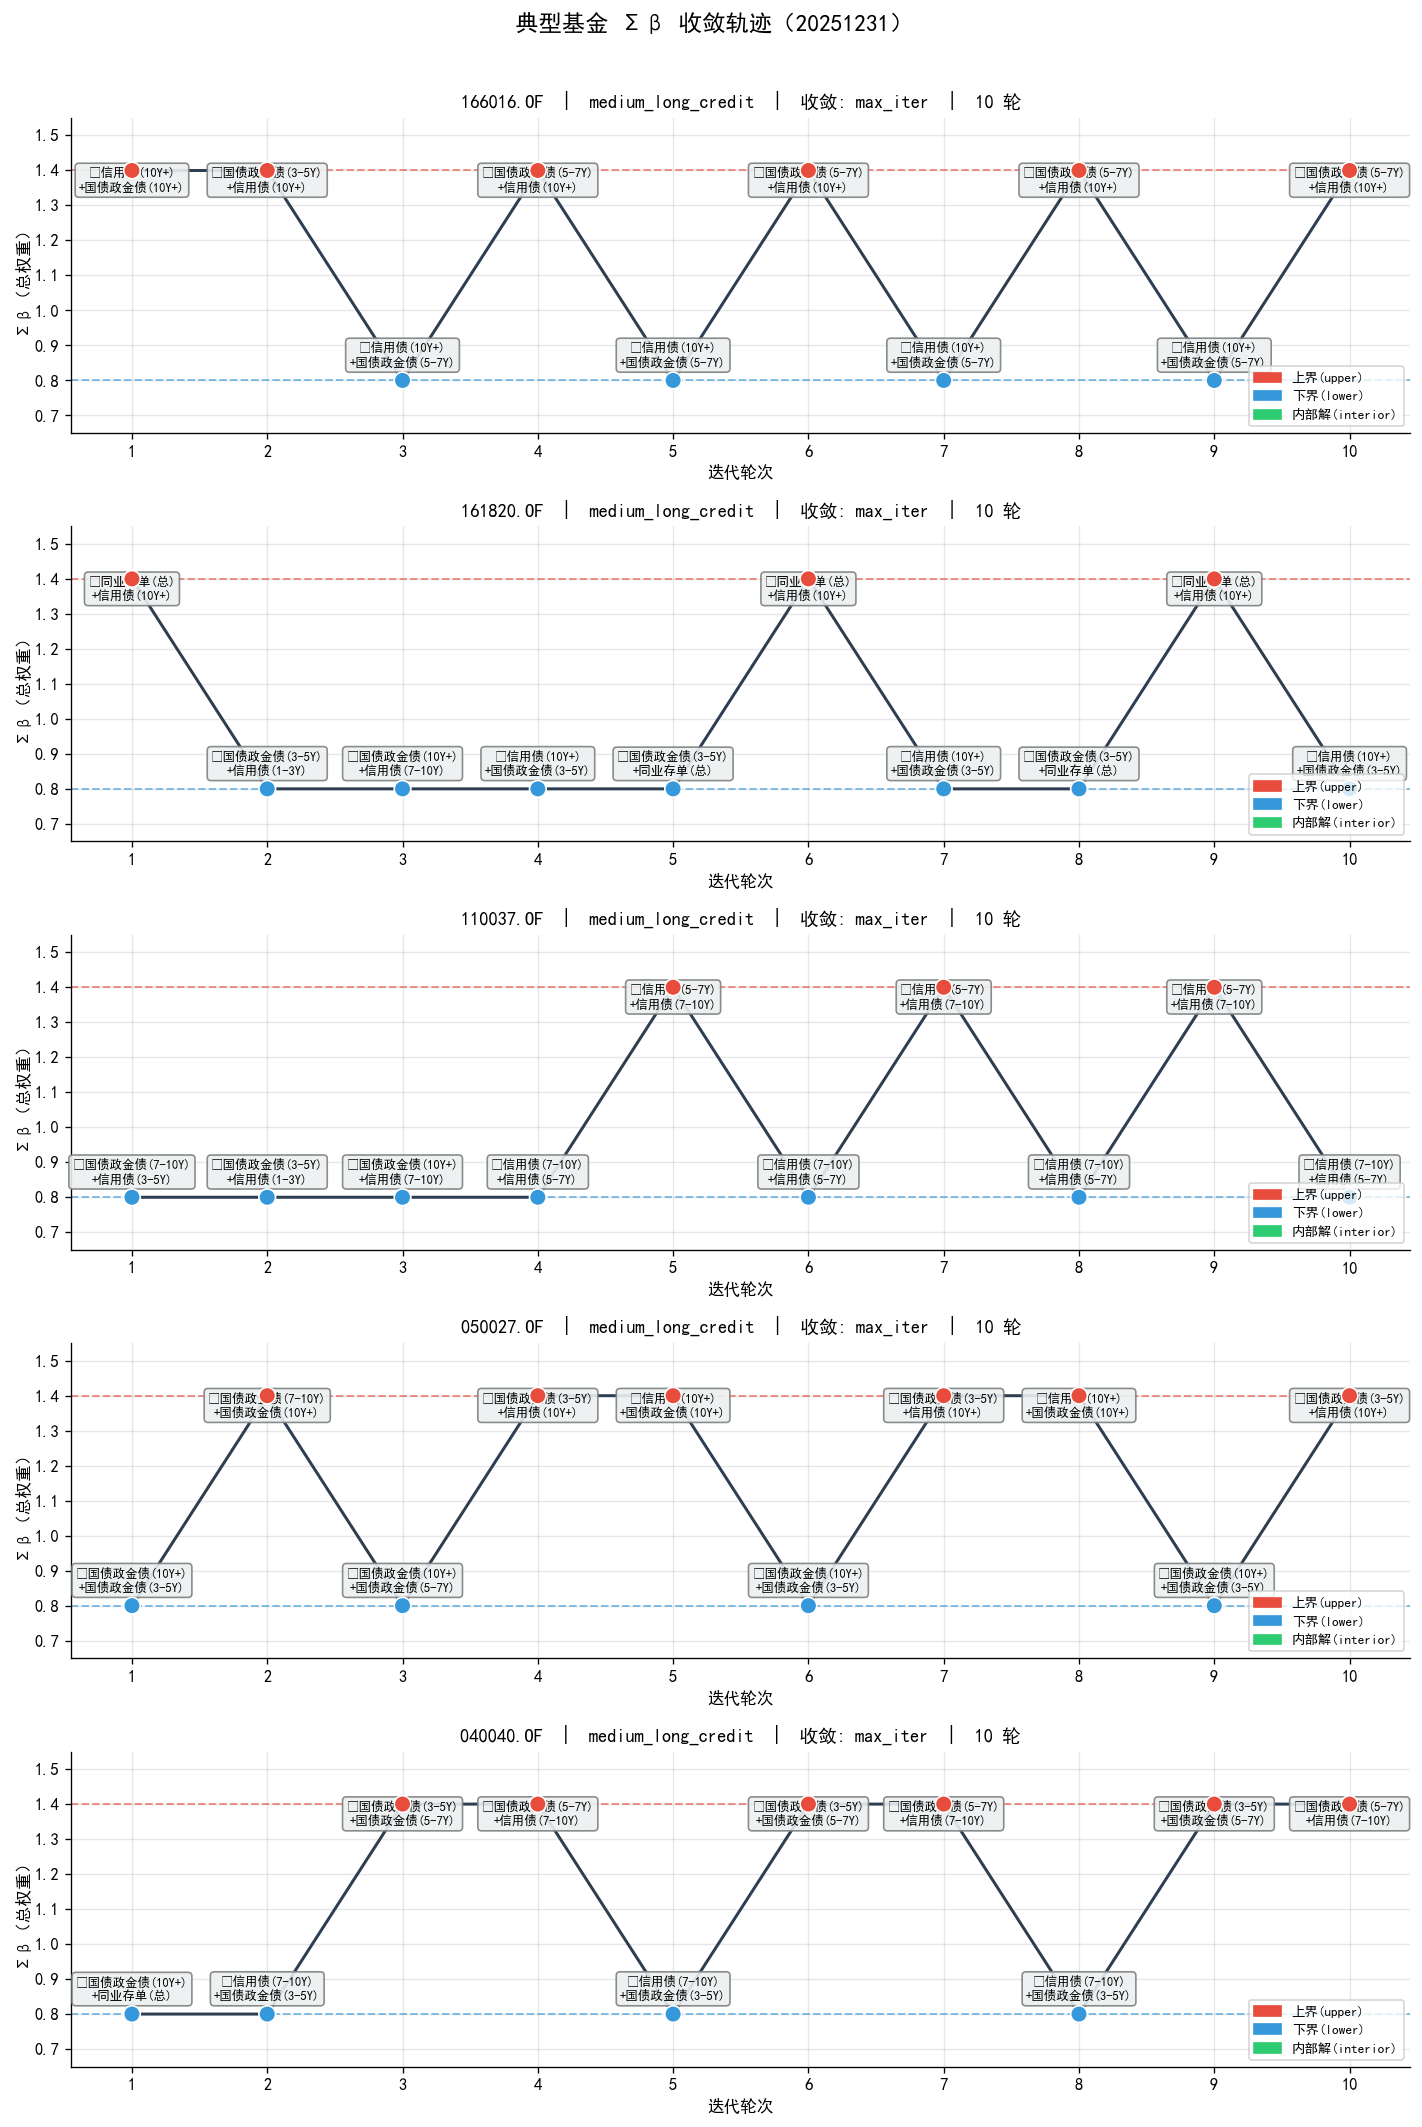

In [8]:
# ── Σβ 收敛轨迹图 ─────────────────────────────────────────────────────────
if len(df_trig) == 0:
    print('跳过。')
else:
    MIN_LEV, MAX_LEV = 0.8, 1.4

    fig, axes = plt.subplots(len(top_funds), 1,
                             figsize=(12, 3.5 * len(top_funds)),
                             squeeze=False)
    fig.suptitle(f'典型基金 Σβ 收敛轨迹（{TARGET_DATE}）', fontsize=14, fontweight='bold', y=1.01)

    for row_i, fund_code in enumerate(top_funds):
        ax = axes[row_i][0]
        sub = df_detail[df_detail['fund_code'] == fund_code].sort_values('round')
        fund_info = df_trig[df_trig['fund_code'] == fund_code].iloc[0]

        rounds   = sub['round'].values
        sum_beta = sub['sum_beta'].values
        bnd_type = sub['boundary_type'].values

        # 颜色编码每个点
        point_colors = []
        for bt in bnd_type:
            if bt == 'upper':   point_colors.append('#e74c3c')
            elif bt == 'lower': point_colors.append('#3498db')
            else:               point_colors.append('#2ecc71')

        ax.plot(rounds, sum_beta, 'o-', color='#2c3e50', linewidth=1.8,
                markersize=8, zorder=3)
        ax.scatter(rounds, sum_beta, c=point_colors, s=100, zorder=4, edgecolors='white')

        # 边界参考线
        ax.axhline(MAX_LEV, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1.2,
                   label=f'上界 {MAX_LEV}')
        ax.axhline(MIN_LEV, color='#3498db', linestyle='--', alpha=0.6, linewidth=1.2,
                   label=f'下界 {MIN_LEV}')

        # 标注因子变化
        for _, detail_row in sub.iterrows():
            r   = detail_row['round']
            sb  = detail_row['sum_beta']
            rem = detail_row.get('factor_removed')
            add = detail_row.get('factor_added')
            parts = []
            if pd.notna(rem): parts.append(f'−{code_to_name(rem)}')
            if pd.notna(add): parts.append(f'+{code_to_name(add)}')
            if parts:
                label_txt = '\n'.join(parts)
                ax.annotate(label_txt,
                            xy=(r, sb),
                            xytext=(r, sb + (0.04 if sb < (MAX_LEV + MIN_LEV)/2 else -0.06)),
                            fontsize=7.5,
                            ha='center',
                            bbox=dict(boxstyle='round,pad=0.3', fc='#ecf0f1', alpha=0.9, ec='gray'),
                            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

        conv = fund_info.get('convergence', '?')
        ftype = f"{fund_info.get('fund_type','?')}_{fund_info.get('bond_type','?')}"
        ax.set_title(f'{fund_code}  |  {ftype}  |  收敛: {conv}  |  {len(rounds)} 轮',
                     fontsize=11)
        ax.set_xlabel('迭代轮次', fontsize=10)
        ax.set_ylabel('Σβ（总权重）', fontsize=10)
        ax.set_xticks(rounds)
        ax.set_ylim(MIN_LEV - 0.15, MAX_LEV + 0.15)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

        # 图例：边界颜色说明
        patch_up  = mpatches.Patch(color='#e74c3c', label='上界(upper)')
        patch_lo  = mpatches.Patch(color='#3498db', label='下界(lower)')
        patch_in  = mpatches.Patch(color='#2ecc71', label='内部解(interior)')
        ax.legend(handles=[patch_up, patch_lo, patch_in],
                  fontsize=8, loc='lower right', framealpha=0.8)

    plt.tight_layout()
    plt.savefig(f'典型基金迭代轨迹_{TARGET_DATE}.png', bbox_inches='tight')
    plt.show()

In [9]:
# ── 典型基金详细迭代过程表格 ───────────────────────────────────────────────
if len(df_trig) > 0:
    print('=' * 80)
    print('典型基金逐轮迭代详情')
    print('=' * 80)
    for fund_code in top_funds:
        sub = df_detail[df_detail['fund_code'] == fund_code].sort_values('round')
        fund_info = df_trig[df_trig['fund_code'] == fund_code].iloc[0]
        print(f'\n【{fund_code}】  {fund_info.get("fund_type","?")}_{fund_info.get("bond_type","?")}  '
              f'收敛: {fund_info.get("convergence","?")}  最终久期: {fund_info.get("final_duration","?")}')
        print(f'  初始因子: {fund_info.get("initial_factors","?")}')
        print(f'  最终因子: {fund_info.get("final_factors","?")}')
        print('-' * 80)
        for _, r in sub.iterrows():
            rem = code_to_name(r['factor_removed']) if pd.notna(r.get('factor_removed')) else '无'
            add = code_to_name(r['factor_added'])   if pd.notna(r.get('factor_added'))   else '无'
            obj = r.get('swap_objective')
            obj_str = f'  swap_Q={obj:.6f}' if pd.notna(obj) else ''
            print(f"  第{int(r['round']):>2}轮  边界:{str(r['boundary_type']):8s}  "
                  f"Σβ={r['sum_beta']:.4f}  移除:{rem}  添加:{add}{obj_str}")
        print()


典型基金逐轮迭代详情

【166016.OF】  medium_long_credit  收敛: max_iter  最终久期: 3.114120027007261
  初始因子: CBA02721.CS, CBA02731.CS, CBA02741.CS, CBA02751.CS, CBA02761.CS, CBA05831.CS, CBA05841.CS, CBA05851.CS, CBA05861.CS, CBA07501.CS
  最终因子: CBA05851.CS, CBA07501.CS, CBA05861.CS, CBA02761.CS
--------------------------------------------------------------------------------
  第 1轮  边界:upper     Σβ=1.4000  移除:信用债(10Y+)  添加:国债政金债(10Y+)
  第 2轮  边界:upper     Σβ=1.4000  移除:国债政金债(3-5Y)  添加:信用债(10Y+)
  第 3轮  边界:lower     Σβ=0.8000  移除:信用债(10Y+)  添加:国债政金债(5-7Y)
  第 4轮  边界:upper     Σβ=1.4000  移除:国债政金债(5-7Y)  添加:信用债(10Y+)
  第 5轮  边界:lower     Σβ=0.8000  移除:信用债(10Y+)  添加:国债政金债(5-7Y)
  第 6轮  边界:upper     Σβ=1.4000  移除:国债政金债(5-7Y)  添加:信用债(10Y+)
  第 7轮  边界:lower     Σβ=0.8000  移除:信用债(10Y+)  添加:国债政金债(5-7Y)
  第 8轮  边界:upper     Σβ=1.4000  移除:国债政金债(5-7Y)  添加:信用债(10Y+)
  第 9轮  边界:lower     Σβ=0.8000  移除:信用债(10Y+)  添加:国债政金债(5-7Y)
  第10轮  边界:upper     Σβ=1.4000  移除:国债政金债(5-7Y)  添加:信用债(10Y+)


【161820.OF】  medium_long_cre

---
## 附录：完整触发基金列表

In [10]:
# 展示所有触发边界的基金（按迭代轮数降序）
if len(df_trig) > 0:
    display_cols = ['fund_code', 'fund_type', 'bond_type', 'total_iterations',
                    'convergence', 'final_duration', 'initial_factors', 'final_factors']
    show_cols = [c for c in display_cols if c in df_trig.columns]
    df_show = df_trig[show_cols].sort_values('total_iterations', ascending=False)
    print(f'共 {len(df_show)} 只基金触发边界调整：')
    pd.set_option('display.max_colwidth', 60)
    pd.set_option('display.max_rows', 100)
    print(df_show.to_string(index=False))
else:
    print('没有基金触发边界调整。')

共 1294 只基金触发边界调整：
fund_code   fund_type bond_type  total_iterations   convergence  final_duration                                                                                                                  initial_factors                                                                                                       final_factors
166016.OF medium_long    credit                10      max_iter        3.114120 CBA02721.CS, CBA02731.CS, CBA02741.CS, CBA02751.CS, CBA02761.CS, CBA05831.CS, CBA05841.CS, CBA05851.CS, CBA05861.CS, CBA07501.CS                                                                  CBA05851.CS, CBA07501.CS, CBA05861.CS, CBA02761.CS
161820.OF medium_long    credit                10      max_iter        4.198926 CBA02721.CS, CBA02731.CS, CBA02741.CS, CBA02751.CS, CBA02761.CS, CBA05831.CS, CBA05841.CS, CBA05851.CS, CBA05861.CS, CBA07501.CS                                                     CBA02731.CS, CBA02741.CS, CBA02721.CS, CBA02751.CS, CBA05831.CS
110037.